In [127]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import GraphicalLassoCV
from scipy.stats import spearmanr
import networkx as nx
import warnings
import re
import os
warnings.filterwarnings("ignore")


output_dir = "Graphical_Lasso_Results"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)


# ============================================================
# 0. Read data and define columns
# ============================================================
CSV_PATH = r"gist_data2_4alldata1.xlsx"  # Adjust path as needed
df = pd.read_excel(CSV_PATH)

def clean_col(c):
    c = str(c).strip().replace("\u200b", "")
    return re.sub(r"\s+", "", c)

df.columns = [clean_col(c) for c in df.columns]

POSTOP_COLS = ["CD34", "CD117", "PDGFR-α", "Dog-1", "S-100", "SMA", "KI-67"]
Y_MUL_NAME = "RiskCategory_encoded"

preop_cols = [c for c in df.columns if c not in POSTOP_COLS + [Y_MUL_NAME]]
postop_cols = [c for c in POSTOP_COLS if c in df.columns]

# 构造数值标签
df["_Y_mul_str"] = df[Y_MUL_NAME].astype(str).str.strip()
df["_Y_mul_num"] = pd.Categorical(df["_Y_mul_str"]).codes.astype(int)

# ============================================================
# 1. Prepare features and target (use all data)
# ============================================================
X_full = df[preop_cols + postop_cols].copy()
y_full = df[Y_MUL_NAME].copy()
if y_full.dtype == 'object':
    y_full = pd.Categorical(y_full).codes

print(f"Total samples: {X_full.shape[0]}")

# ============================================================
# 2. Preprocessing: one‑hot encoding + standardisation (on full data)
# ============================================================
num_cols = [c for c in X_full.columns if pd.api.types.is_numeric_dtype(X_full[c])]
cat_cols = [c for c in X_full.columns if c not in num_cols]

X_enc = pd.get_dummies(X_full, columns=cat_cols, drop_first=False)
# Remove constant features (zero variance)
non_const = X_enc.columns[X_enc.std() > 0]
X_enc = X_enc[non_const]

scaler = StandardScaler()
X_z = scaler.fit_transform(X_enc)
feature_names = X_enc.columns.tolist()
print(f"Number of features after preprocessing: {len(feature_names)}")

# ============================================================
# 3. Graphical Lasso estimation (on full data)
# ============================================================
gl = GraphicalLassoCV(
    alphas=4,
    cv=5,
    n_refinements=4,
    tol=1e-4,
    max_iter=100,
    mode='cd',
)
gl.fit(X_z)

print(f"Optimal regularisation parameter λ (alpha): {gl.alpha_:.6f}")
print("λ selection method: 5‑fold cross‑validation (GraphicalLassoCV)")
print("Algorithm: coordinate descent (mode='cd')")
print(f"Convergence tolerance: tol=1e-4, max_iter=100")

Theta = gl.precision_
d = np.sqrt(np.diag(Theta))
partial_corr = -Theta / (np.outer(d, d) + 1e-12)
np.fill_diagonal(partial_corr, 0)

# ============================================================
# 4. Node strength (replaces "precision‑matrix importance")
# ============================================================
node_strength = {}
for i, feat in enumerate(feature_names):
    strength = np.sum(np.abs(partial_corr[i, :]))
    node_strength[feat] = strength
df_strength = pd.DataFrame(list(node_strength.items()), columns=["feature", "node_strength"])

# ============================================================
# 5. Spearman correlation with risk category
# ============================================================
spearman_dict = {}
for i, feat in enumerate(feature_names):
    x_col = X_z[:, i]
    if np.std(x_col) < 1e-8:
        continue
    rho, _ = spearmanr(x_col, y_full)
    spearman_dict[feat] = abs(rho)
df_spearman = pd.DataFrame(list(spearman_dict.items()), columns=["feature", "Correlation coefficient"])

# ============================================================
# 6. PageRank based on the partial correlation network
# ============================================================
print('feature_names is',feature_names)
G = nx.Graph()
G.add_nodes_from(feature_names)
for i in range(len(feature_names)):
    for j in range(i+1, len(feature_names)):
        w = abs(partial_corr[i, j])
        if w > 1e-6:
            G.add_edge(feature_names[i], feature_names[j], weight=w)

pagerank_dict = nx.pagerank(G, weight='weight')
df_pagerank = pd.DataFrame(list(pagerank_dict.items()), columns=["feature", "pagerank"])

# ============================================================
# 7. Merge the three metrics and normalise
# ============================================================
df_merged = df_spearman.merge(df_strength, on='feature', how='inner')
df_merged = df_merged.merge(df_pagerank, on='feature', how='inner')
print(f"Valid features after merging: {len(df_merged)}")

for metric in ['Correlation coefficient', 'node_strength', 'pagerank']:
    minv, maxv = df_merged[metric].min(), df_merged[metric].max()
    df_merged[f'{metric}_norm'] = (df_merged[metric] - minv) / (maxv - minv)

# ============================================================
# 8. Random weight sensitivity analysis (Dirichlet, 500 draws)
# ============================================================
np.random.seed(42)
n_random = 500
random_weights = np.random.dirichlet(alpha=(1,1,1), size=n_random)

df_merged = df_merged.reset_index(drop=True)

stability_counts = {feat: 0 for feat in df_merged['feature']}
for w in random_weights:
    w1, w2, w3 = w
    score = (w1 * df_merged['Correlation coefficient_norm'] +
             w2 * df_merged['node_strength_norm'] +
             w3 * df_merged['pagerank_norm'])
    sorted_idx = score.sort_values(ascending=False).index
    top10 = df_merged.loc[sorted_idx, 'feature'].head(10).tolist()
    for feat in top10:
        stability_counts[feat] += 1

df_stability = pd.DataFrame(list(stability_counts.items()), columns=['feature', 'count'])
df_stability['prob'] = df_stability['count'] / n_random
df_stability = df_stability.sort_values('prob', ascending=False).reset_index(drop=True)

print("\nFeature stability (probability of being in top‑10 across 500 random weight draws):")
print(df_stability.head(10).to_string(index=False))

# ============================================================
# 9. Select final top‑10 features and merge with metrics
# ============================================================
selected_feature = df_stability.head(10)['feature'].tolist()

# Merge original metrics
df_stability = df_stability.merge(
    df_merged[['feature', 'Correlation coefficient', 'pagerank', 'node_strength']],
    on='feature', how='left'
)
df_stability = df_stability.sort_values('prob', ascending=False).reset_index(drop=True)

# Save results
df_stability.to_csv(os.path.join(output_dir, "feature_stability_with_metrics.csv"), index=False, encoding='utf-8-sig')


Total samples: 433
Number of features after preprocessing: 18
Optimal regularisation parameter λ (alpha): 0.070863
λ selection method: 5‑fold cross‑validation (GraphicalLassoCV)
Algorithm: coordinate descent (mode='cd')
Convergence tolerance: tol=1e-4, max_iter=100
feature_names is ['KI_67', 'MaximumTumorSize', 'Location', 'ShapeRegularity', 'Ulceration', 'OriginLayer', 'Echo', 'EchoUniformity', 'GrowthPattern', 'BoundaryClarity', 'EndoscopicUltrasoundType', 'BloodFlowSignal', 'CD34', 'CD117', 'PDGFR-α', 'Dog-1', 'S-100', 'SMA']
Valid features after merging: 18

Feature stability (probability of being in top‑10 across 500 random weight draws):
                 feature  count  prob
                   KI_67    500 1.000
                   Dog-1    500 1.000
         ShapeRegularity    500 1.000
              Ulceration    500 1.000
                   CD117    500 1.000
        MaximumTumorSize    500 1.000
EndoscopicUltrasoundType    500 1.000
         BloodFlowSignal    475 0.950
      

节点: 19, 边: 56


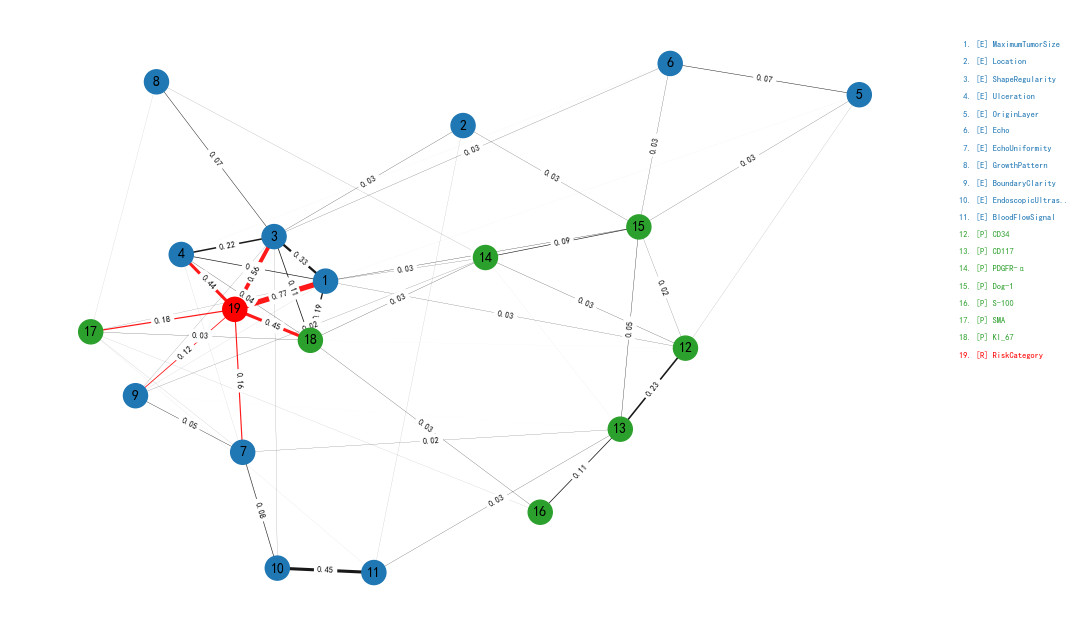

In [138]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import re
import os
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import GraphicalLassoCV
from scipy.stats import spearmanr


EDGE_THRESHOLD = 0      
OUTPUT_DIR = "Graphical_Lasso_Results"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)


CSV_PATH = r"gist_data2_4alldata1.xlsx"  
df = pd.read_excel(CSV_PATH)

def clean_col(c):
    c = str(c).strip().replace("\u200b", "")
    return re.sub(r"\s+", "", c)

df.columns = [clean_col(c) for c in df.columns]

POSTOP_COLS = ["CD34", "CD117", "PDGFR-α", "Dog-1", "S-100", "SMA", "KI_67"]
Y_MUL_NAME = "RiskCategory_encoded"
preop_cols = [c for c in df.columns if c not in POSTOP_COLS + [Y_MUL_NAME]]
postop_cols = [c for c in POSTOP_COLS if c in df.columns]

df["_Y_mul_str"] = df[Y_MUL_NAME].astype(str).str.strip()
df["_Y_mul_num"] = pd.Categorical(df["_Y_mul_str"]).codes.astype(int)
y_full = df[Y_MUL_NAME].copy()
if y_full.dtype == 'object':
    y_full = pd.Categorical(y_full).codes


X_full = df[preop_cols + postop_cols].copy()
num_cols = [c for c in X_full.columns if pd.api.types.is_numeric_dtype(X_full[c])]
cat_cols = [c for c in X_full.columns if c not in num_cols]
X_enc = pd.get_dummies(X_full, columns=cat_cols, drop_first=False)
non_const = X_enc.columns[X_enc.std() > 0]
X_enc = X_enc[non_const]
scaler = StandardScaler()
X_z = scaler.fit_transform(X_enc)

feature_names = X_enc.columns.tolist()


# Graphical Lasso 
gl = GraphicalLassoCV(alphas=4, cv=5, n_refinements=4, tol=1e-4, max_iter=100, mode='cd')
gl.fit(X_z)
Theta = gl.precision_
d = np.sqrt(np.diag(Theta))
partial_corr = -Theta / (np.outer(d, d) + 1e-12)
np.fill_diagonal(partial_corr, 0)

# Spearman
spearman_dict = {}
for i, feat in enumerate(feature_names):
    x_col = X_z[:, i]
    if np.std(x_col) < 1e-8:
        continue
    rho, _ = spearmanr(x_col, y_full)
    spearman_dict[feat] = abs(rho)
df_spearman = pd.DataFrame(list(spearman_dict.items()), columns=["feature", "Correlation coefficient"])



G = nx.Graph()
for feat in feature_names:
    G.add_node(feat, type='feature')
risk_node = 'RiskCategory'
G.add_node(risk_node, type='risk')
for i in range(len(feature_names)):
    for j in range(i+1, len(feature_names)):
        w = abs(partial_corr[i, j])
        if w > 1e-6:
            G.add_edge(feature_names[i], feature_names[j], weight=w, kind='feature-feature')
        
for idx, row in df_spearman.iterrows():
    feat = row['feature']
    rho = row['Correlation coefficient']
    if rho > 0.1:
        G.add_edge(feat, risk_node, weight=rho, kind='feature-risk')
        
print(f"节点: {G.number_of_nodes()}, 边: {G.number_of_edges()}")


def get_category(node):
    if node == risk_node:
        return 'risk'
    for kw in postop_cols:
        if node == kw or node.startswith(kw + '_'):
            return 'path'
    for kw in preop_cols:
        if node == kw or node.startswith(kw + '_'):
            return 'eus'
    return 'other'
for node in G.nodes():
    G.nodes[node]['category'] = get_category(node)
color_map = {'eus': '#1f77b4', 'path': '#2ca02c', 'risk': 'red', 'other': 'gray'}
node_colors = [color_map[G.nodes[n]['category']] for n in G.nodes()]


pos = nx.spring_layout(G, seed=42, k=0.9, iterations=1000)  

pos[risk_node] = np.array([0, 0])
fixed_nodes = {risk_node: pos[risk_node]}


pos = nx.spring_layout(G, pos=pos, fixed=fixed_nodes,seed=42, k=0.9, iterations=1000)


fig, ax = plt.subplots(figsize=(12, 8))   # 宽高比约2.67：1,(12, 6)


edges_ff = [(u, v) for u, v, d in G.edges(data=True) if d['kind'] == 'feature-feature']
edges_fr = [(u, v) for u, v, d in G.edges(data=True) if d['kind'] == 'feature-risk']

if edges_ff:
    weights_ff = [G[u][v]['weight'] for u, v in edges_ff]
    nx.draw_networkx_edges(G, pos, edgelist=edges_ff,
                           width=[w * 5 for w in weights_ff],
                           edge_color='black', alpha=0.9, ax=ax)
if edges_fr:
    weights_fr = [G[u][v]['weight'] for u, v in edges_fr]
    nx.draw_networkx_edges(G, pos, edgelist=edges_fr,
                           width=[w * 5 for w in weights_fr],
                           edge_color='red', alpha=0.9, ax=ax)


nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300, ax=ax)


node_list = list(G.nodes())
node_to_num = {node: i+1 for i, node in enumerate(node_list)}
labels = {node: str(node_to_num[node]) for node in node_list}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight='bold', ax=ax)


edge_labels = {}
for u, v, d in G.edges(data=True):
    if d['weight'] > 0.02:
        edge_labels[(u, v)] = f"{d['weight']:.2f}"
    
if edge_labels:
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,font_size=6, ax=ax)  # 字体调小以容纳更多标签


x_start = 1.02
y_start = 0.95
y_step = 0.028

for node, num in node_to_num.items():
    cat = G.nodes[node]['category']
    if cat == 'eus':
        col, mark = '#1f77b4', '[E]'
    elif cat == 'path':
        col, mark = '#2ca02c', '[P]'
    elif cat == 'risk':
        col, mark = 'red', '[R]'
    else:
        col, mark = 'gray', '[?]'
    short_name = node if len(node) <= 18 else node[:16] + '..'
    ax.text(x_start, y_start, f"{num:2d}. {mark} {short_name}",
            transform=ax.transAxes, fontsize=6, color=col, verticalalignment='top')
    y_start -= y_step

#ax.set_title('Graphical Lasso Feature Interaction Network', fontsize=12)
ax.axis('off')
#plt.tight_layout(rect=[0, 0, 0.89, 1])  # 右侧留出22%空间
#plt.savefig(os.path.join(OUTPUT_DIR, 'network_flat.png'), dpi=300, bbox_inches='tight')
plt.show()